# 3. Customer Segmentation

## RFM Analysis

In [5]:
df_model = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/KPMG/df_model.csv')
df_model.columns

Index(['transaction_id', 'product_id', 'customer_id', 'transaction_date',
       'order_status', 'brand', 'product_line', 'product_class',
       'product_size', 'list_price', 'standard_cost',
       'product_first_sold_date_clean', 'online_order_cleaned', 'profit',
       'first_name', 'last_name', 'gender',
       'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'owns_car', 'tenure', 'age', 'address', 'postcode', 'state', 'country',
       'property_valuation', 'age_group'],
      dtype='object')

In [6]:
customers_nmb = len(df_model['customer_id'].unique())
print('# of customers:', customers_nmb)
df_shape = df_model.shape
print('df shape:', df_shape)

# of customers: 2519
df shape: (13910, 32)


In [7]:
# adding column for recency as diff between recent day and transaction_day
recent_day = pd.to_datetime(df_model['transaction_date'].max())
df_model['recency'] = (recent_day -  pd.to_datetime(df_model['transaction_date'])).dt.days
df_model[['transaction_date', 'recency']].head()

,transaction_date,recency
0,2017-02-25,308
1,2017-10-16,75
2,2017-04-26,248
3,2017-05-21,223
4,2017-10-05,86


In [8]:
# creating rfm dataframe
columns = ['recency', 'transaction_id', 'profit']
calc = {'recency': 'min', 'transaction_id': 'count', 'profit': 'sum'}
fields_name = {'recency': 'recency', 'transaction_id': 'frequency', 'profit': 'monetary'}
df_rfm = df_model.pivot_table(index = 'customer_id', values = columns, aggfunc = calc).rename(columns = fields_name)
df_rfm.head()

,monetary,recency,frequency
customer_id,,,
1,3018.09,7,11
2,2226.26,128,3
9,2353.11,78,6
12,3540.03,67,7
13,4337.38,27,7


In [9]:
# calculating statistics for each column
r_stat = {
    'min': df_rfm['recency'].min(),
    'low_quartile': np.percentile(df_rfm['recency'], 25),
    'median': np.median(df_rfm['recency']),
    'high_quartile': np.percentile(df_rfm['recency'], 75),
    'max': df_rfm['recency'].max()
}

f_stat = {
    'min': df_rfm['frequency'].min(),
    'low_quartile': np.percentile(df_rfm['frequency'], 25),
    'median': np.median(df_rfm['frequency']),
    'high_quartile': np.percentile(df_rfm['frequency'], 75),
    'max': df_rfm['frequency'].max()
}

m_stat = {
    'min': df_rfm['monetary'].min(),
    'low_quartile': np.percentile(df_rfm['monetary'], 25),
    'median': np.median(df_rfm['monetary']),
    'high_quartile': np.percentile(df_rfm['monetary'], 75),
    'max': df_rfm['monetary'].max()
}
m_stat

{'min': 15.080000000000004,
 'low_quartile': 1766.355,
 'median': 2785.0400000000004,
 'high_quartile': 4063.625,
 'max': 11668.949999999999}

In [10]:
# function to calculate score_field
def calculate_score(column, stats):
  return np.where(column <= stats['low_quartile'], 4,
                               np.where(column <= stats['median'], 3,
                                        np.where(column <= stats['high_quartile'], 2, 1)))

In [11]:
# adding score columns
df_rfm['r_score'] = calculate_score(df_rfm['recency'], r_stat)
df_rfm['f_score'] = calculate_score(df_rfm['frequency'], f_stat)
df_rfm['m_score'] = calculate_score(df_rfm['monetary'], m_stat)

In [12]:
# creating Customer`s profile
df_rfm['rfm_profile'] = (df_rfm['r_score'].astype(str)+df_rfm['f_score'].astype(str)+df_rfm['m_score'].astype(str)).astype(int)

In [13]:
# Define a function to determine the category
def determine_category(rfm):
    if rfm >= 411:
        return 'Platinum'
    elif rfm >= 311:
        return 'Gold'
    elif rfm >= 211:
        return 'Silver'
    else:
        return 'Bronze'

# Apply the function to create the 'Category' column
df_rfm['customer_category'] = df_rfm.apply(lambda row: determine_category(row['rfm_profile']), axis=1)
df_rfm['customer_category'].value_counts()

Platinum    639
Gold        630
Bronze      628
Silver      622
Name: customer_category, dtype: int64

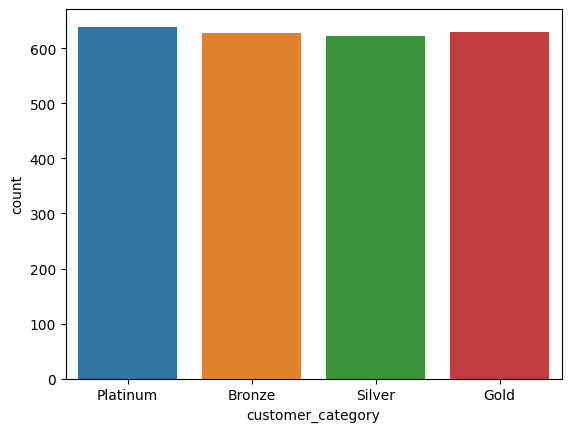

In [15]:
sns.countplot(x = 'customer_category',
             data = df_rfm)
            #  hue = 'location',)
plt.show()

In [174]:
# creating RFM matrix
df_rfm_heat = df_rfm.pivot_table(index=['r_score', 'f_score'], columns='m_score', values='monetary', aggfunc='count', fill_value=0)
df_rfm_heat = df_rfm_heat.sort_index(ascending=[False, False])
df_rfm_heat = df_rfm_heat.sort_index(axis=1, ascending=False)
df_rfm_heat.head()

m_score           4   3   2    1
r_score f_score                 
4       4        75  45  27    7
        3        16  43  33   14
        2        21  60  65   59
        1         0  14  43  117
3       4        86  52  24    3

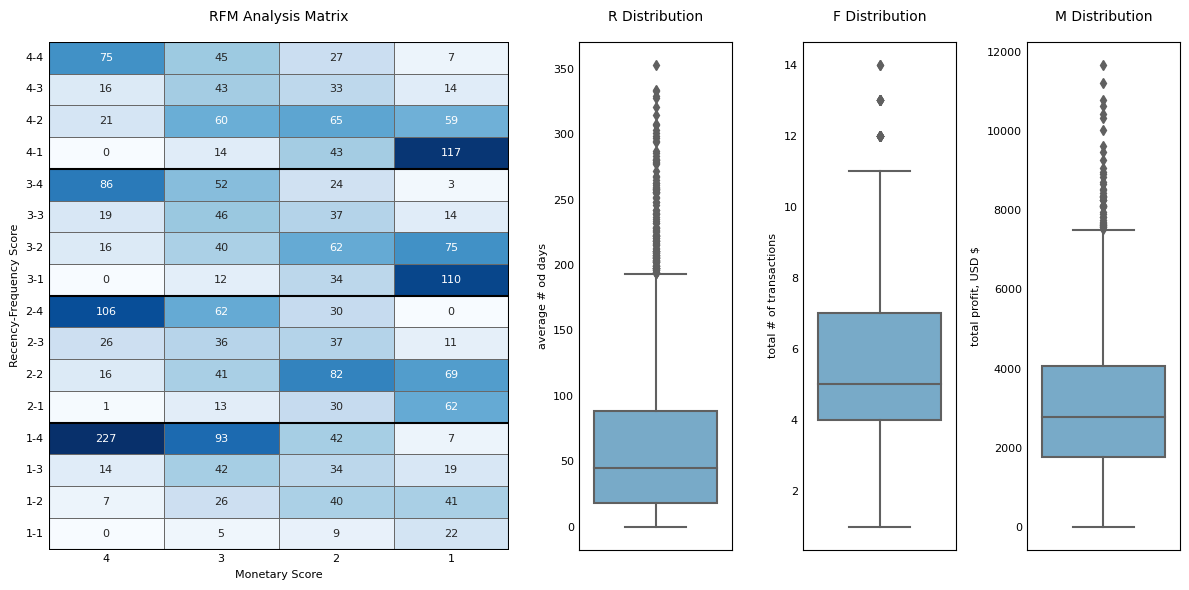

In [ ]:
# Create RFM visualization

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 4, width_ratios=[3, 1, 1,1])

# Create a heatmap using seaborn with conditional formatting
ax1 = plt.subplot(gs[0])
sns.heatmap(df_rfm_heat,
            vmin=0, vmax=120,
            annot=True,
            cmap='Blues',
            fmt='d',
            annot_kws={'size': 8},
            linewidths=.5, linecolor='dimgrey',
            cbar=False, ax=ax1)
ax1.set_title('RFM Analysis Matrix', fontsize=10, color='black', pad=15)
ax1.set_xlabel('Monetary Score', fontsize=8)
ax1.set_ylabel('Recency-Frequency Score', fontsize=8)
ax1.tick_params(axis='both', which='both', length=0, rotation=0, labelsize=8)

# add frame around the heatmap
ax1.axvline(x = 4, color = "k")
ax1.axvline(x = 0, color = "k")
ax1.axhline(y = 16, color = "k")
ax1.axhline(y = 0, color = "k")

# add lines to separate Recency sections
ax1.axhline(y = 12, color = "k")
ax1.axhline(y = 8, color = "k")
ax1.axhline(y = 4, color = "k")

# Plot for Recency
ax2 = plt.subplot(gs[1])
sns.boxplot(y ='recency', data = df_rfm, palette='Blues', ax=ax2)
ax2.set_title('R Distribution', fontsize=10, color='black', pad=15)
ax2.set_ylabel('average # od days',fontsize=8)
ax2.tick_params(axis='both', which='both', length=0, rotation=0, labelsize=8)

# Plot for Frequency
ax3 = plt.subplot(gs[2])
sns.boxplot(y='frequency', data=df_rfm, palette='Blues', ax=ax3)
ax3.set_title('F Distribution', fontsize=10, color='black', pad=15)
ax3.set_ylabel('total # of transactions',fontsize=8)
ax3.tick_params(axis='both', which='both', length=0, rotation=0, labelsize=8)

# Plot for Monetary
ax4 = plt.subplot(gs[3])
sns.boxplot(y='monetary', data=df_rfm, palette='Blues', ax=ax4)
ax4.set_title('M Distribution', fontsize=10, color='black', pad=15)
ax4.set_ylabel('total profit, USD $',fontsize=8)
ax4.tick_params(axis='both', which='both', length=0, rotation=0, labelsize=8)

# Adjust layout
plt.tight_layout()
plt.show()

## Cohort Retention Analysis

In [26]:
# data for cohorts
df_transactions_clean.head()
cond_1 = df_transactions_clean['order_status']!='Cancelled'
df_cohort = df_transactions_clean[cond_1].copy()

In [27]:
df_cohort = df_cohort[['customer_id', 'transaction_date']]
df_cohort['transaction_month'] = pd.to_datetime(df_cohort['transaction_date']).dt.month
df_cohort['nmb_months_diff'] = df_cohort['transaction_month'] - df_cohort['transaction_month'].min()
df_cohort.head()

,customer_id,transaction_date,transaction_month,nmb_months_diff
0,2950,2017-02-25,2,1
1,3120,2017-05-21,5,4
2,402,2017-10-16,10,9
3,3135,2017-08-31,8,7
4,787,2017-10-01,10,9


In [28]:
df_cohort_month = df_cohort.groupby('customer_id')['nmb_months_diff'].min().reset_index()
df_cohort_month.rename(columns={'nmb_months_diff':'cohort'}, inplace = True)
df_cohort_month.head()

,customer_id,cohort
0,1,0
1,2,4
2,3,1
3,4,3
4,5,2


In [29]:
# joining all transactions and first month transaction
df_cohort_retention = df_cohort.join(df_cohort_month.set_index('customer_id'), on = 'customer_id')
df_cohort_retention['month_nmb'] = df_cohort_retention['nmb_months_diff']-df_cohort_retention['cohort']
df_cohort_retention_clean = df_cohort_retention[['customer_id', 'cohort', 'month_nmb']].copy()
df_cohort_retention_clean=df_cohort_retention_clean.drop_duplicates(subset = ['customer_id', 'cohort', 'month_nmb'], keep = 'first')
df_cohort_retention_clean.sort_values(by='customer_id')

,customer_id,cohort,month_nmb
93,1,0,11
14485,1,0,2
9784,1,0,0
15662,1,0,5
3764,1,0,3
...,...,...,...
2462,3500,0,3
8415,3500,0,1
19835,3500,0,2
8707,5034,0,9


In [30]:
# calculating # of customers for each cohort and month_nmb
df_retention = df_cohort_retention_clean.groupby(['cohort', 'month_nmb'])['customer_id'].count().reset_index()
df_retention = df_retention.pivot_table(values = 'customer_id', columns = 'month_nmb', index = 'cohort')

In [31]:
# calculating rates
df_retention = df_retention.divide(df_retention.iloc[:,0], axis=0).round(3)*100
df_retention = df_retention.iloc[:,1:]
df_retention

month_nmb,1,2,3,4,5,6,7,8,9,10,11
cohort,,,,,,,,,,,
0,35.8,37.0,36.4,36.0,35.1,37.6,38.7,36.0,38.4,36.4,37.5
1,39.7,36.9,38.9,35.2,37.0,38.2,35.0,40.5,37.4,36.2,NaN
2,34.6,35.2,33.3,37.3,37.3,35.0,42.4,38.5,37.9,NaN,NaN
3,32.7,35.6,45.5,42.3,34.7,42.3,36.7,37.9,NaN,NaN,NaN
4,40.2,37.9,40.7,35.0,33.6,35.0,38.8,NaN,NaN,NaN,NaN
5,36.0,36.8,39.2,36.8,36.0,42.4,NaN,NaN,NaN,NaN,NaN
6,34.6,32.1,42.3,47.4,30.8,NaN,NaN,NaN,NaN,NaN,NaN
7,33.3,43.1,35.3,25.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,33.3,29.2,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


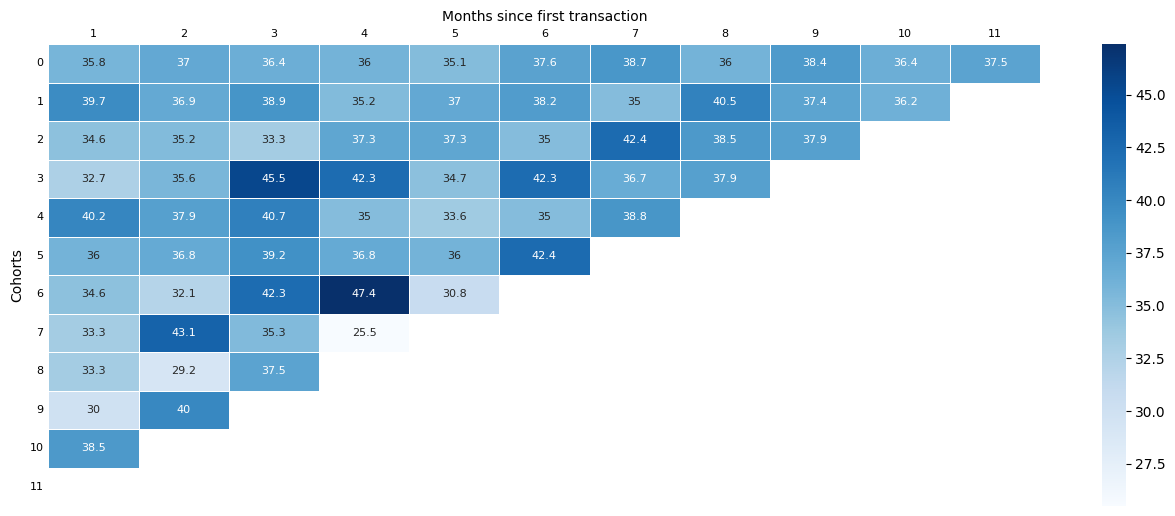

In [32]:
# creating a heatmap
fig, ax = plt.subplots(1,1,figsize=(16,6))
sns.heatmap(df_retention, annot=True, cmap='Blues',annot_kws={'size': 8},fmt='g',linewidths=.5)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.xaxis.set_label_coords(0.5, 1.05)

ax.set_xlabel('Months since first transaction')
ax.set_ylabel('Cohorts')
ax.tick_params(axis='both', which='both', length=0, rotation=0, labelsize=8)

# Reverse the order of x-axis labels
xticks = ax.get_xticks()
ax.set_xticks(xticks[::-1])
ax.set_xticklabels(df_retention.columns[::-1])

plt.show()